## Importing the relevant packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as sgt
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats.distributions import chi2 
import seaborn as sns
sns.set()

## Importing the Data and Pre-processing 

In [2]:
raw_csv_data = pd.read_csv("Index2018.csv") 
df_comp=raw_csv_data.copy()
df_comp.date = pd.to_datetime(df_comp.date, dayfirst = True)
df_comp.set_index("date", inplace=True)
df_comp=df_comp.asfreq('b')
df_comp=df_comp.ffill()

In [3]:
df_comp['market_value']=df_comp.ftse

In [4]:
del df_comp['spx']
del df_comp['dax']
del df_comp['ftse']
del df_comp['nikkei']
size = int(len(df_comp)*0.8)
df, df_test = df_comp.iloc[:size], df_comp.iloc[size:]

In [5]:
import warnings
warnings.filterwarnings("ignore")

## The LLR Test

In [6]:
def LLR_test(mod_1, mod_2, DF = 1):
    L1 = mod_1.fit().llf
    L2 = mod_2.fit().llf
    LR = (2*(L2-L1))    
    p = chi2.sf(LR, DF).round(3)
    return p

## Creating Returns

In [7]:
df['returns'] = df.market_value.pct_change(1)*100

### Creating AR(1) And MA(1) Models to compare with ARMA(1,1) model

In [8]:
model_ret_ar_1 = ARIMA(df.returns,order=(1,0,0))
result_ret_ar_1 = model_ret_ar_1.fit()

model_ret_ma_1 = ARIMA(df.returns,order=(0,0,1))
result_ret_ma_1 = model_ret_ma_1.fit()

## ARMA(1,1)

In [9]:
# Forming ARMA(1,1)
model_ret_ar1_ma1 = ARIMA(df.returns, order=(1,0,1))
result_ret_ar1_ma1 = model_ret_ar1_ma1.fit()
print(result_ret_ar1_ma1.summary())
print()
print("LLR Test Against Individual AR and MA Models")
print(f'AR(1)vsARMA(1,1) -> {LLR_test(model_ret_ar_1,model_ret_ar1_ma1)}')
print(f'MA(1)vsARMA(1,1) -> {LLR_test(model_ret_ma_1,model_ret_ar1_ma1)}')

                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                 5021
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -7916.500
Date:                Mon, 27 Apr 2026   AIC                          15841.000
Time:                        20:51:54   BIC                          15867.085
Sample:                    01-07-1994   HQIC                         15850.140
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0189      0.015      1.290      0.197      -0.010       0.048
ar.L1          0.7650      0.045     16.995      0.000       0.677       0.853
ma.L1         -0.8142      0.040    -20.187      0.0

`This summary clearly shows that AR coefficient and MA coefficient are both significant`

`LLR Test Concludes that ARMA(1,1) is better than standalone AR(1) and MA(1) models`

#### Important Conclusion

`Both AR and MA coefficient are significant`                                                                              
`NOTE :: AR and MA coefficients being large, opposite, and nearly equal indicate near cancellation, implying the return series is effectively white noise with no meaningful linear predictability, and ARMA is just fitting noise.`

In [17]:
# This can be confirmed if I plot Residuals of ARMA(1,1) it should already be like white noise
df['resid_ret_ar1_ma1'] = result_ret_ar1_ma1.resid[1:]

In [18]:
df.head()

,market_value,returns,resid_ret_ar1_ma1
date,,,
1994-01-07,3445.98,NaN,NaN
1994-01-10,3440.58,-0.156704,-0.175606
1994-01-11,3413.77,-0.779229,-0.805937
1994-01-12,3372.02,-1.222988,-1.284980
1994-01-13,3360.01,-0.356166,-0.468570


In [21]:
# Checking Augmented Dickey Fuller to See if the Residuals are Stationary
sts.adfuller(df.resid_ret_ar1_ma1[1:])

(np.float64(-12.480691685253328),
 np.float64(3.0962932084129505e-23),
 32,
 4987,
 {'1%': np.float64(-3.431661944885779),
  '5%': np.float64(-2.8621197374408225),
  '10%': np.float64(-2.5670785949998973)},
 np.float64(15696.420369259125))

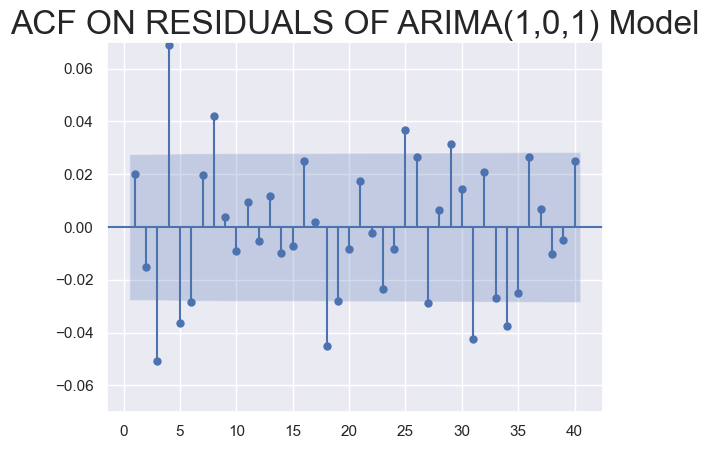

In [26]:
sgt.plot_acf(df.resid_ret_ar1_ma1[1:],zero=False,lags=40)
plt.ylim(-.07,.07)
plt.title("ACF ON RESIDUALS OF ARIMA(1,0,1) Model",size=24)
plt.show()

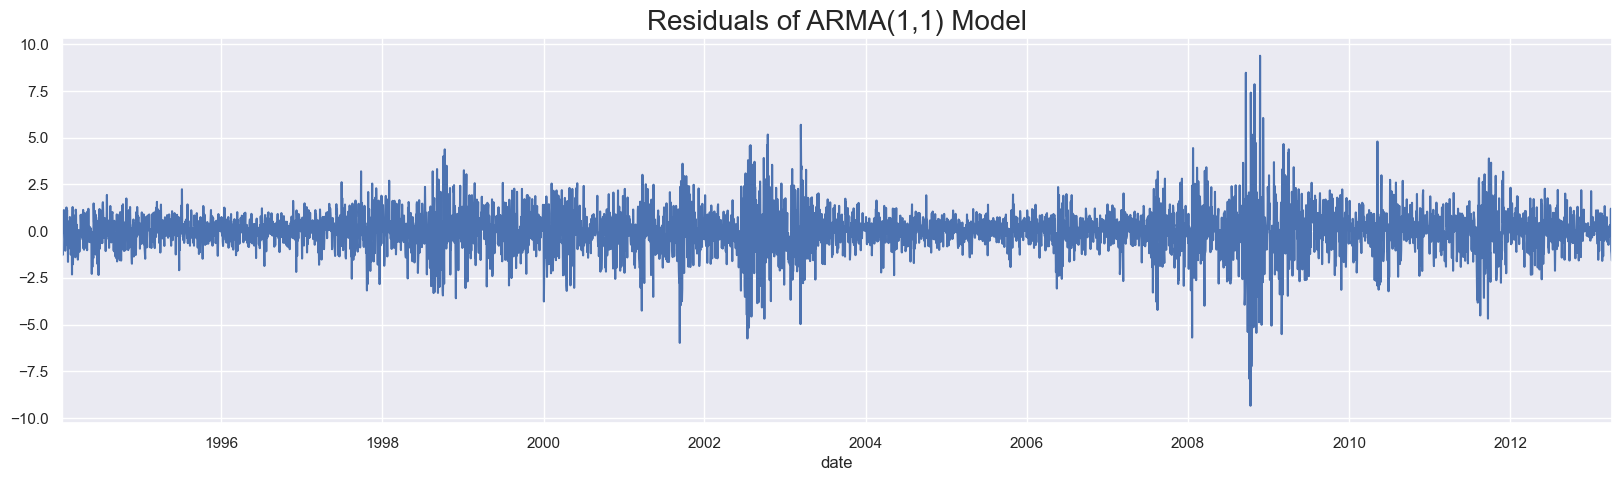

In [22]:
df.resid_ret_ar1_ma1[1:].plot(figsize=(20,5))
plt.title("Residuals of ARMA(1,1) Model",size=20)
plt.show()

## Higher-Lag ARMA Models

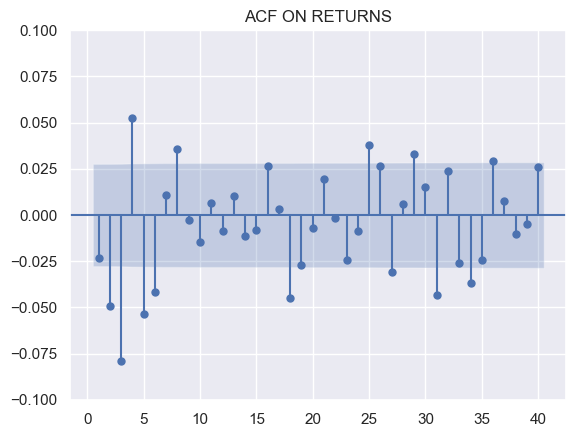

In [32]:
# PACF ON Returns and ACF On returns
sgt.plot_acf(df.returns[1:],zero=False,lags=40)
plt.title("ACF ON RETURNS")
plt.ylim(-.1,.1)
plt.show()

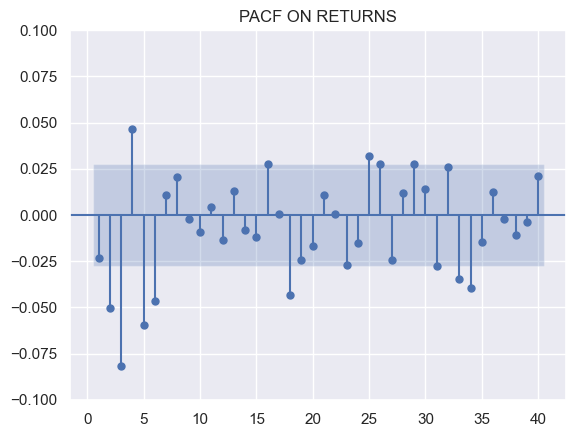

In [34]:
sgt.plot_pacf(df.returns[1:],zero=False,lags=40,method=('ols'),alpha=0.05)
plt.title("PACF ON RETURNS")
plt.ylim(-.1,.1)
plt.show()

`From PACF we see that best fit AR model is AR(6)`                                                                     
`From ACF we see that best fit MA Model is MA(8)`                                                                       
`Thus we start with ARMA(6,8) Model`

In [ ]:
# We will firstly make an overfitted model and check the Significant variables and then reduce the complexity to 
# achieve the best fit model
# Let us Make ARIMA(6,8) Model 

In [35]:
model_ret_ar6_ma8 = ARIMA(df.returns[1:], order=(6,0,8))
result_ret_ar6_ma8 = model_ret_ar6_ma8.fit()
print(result_ret_ar6_ma8.summary())

                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                 5020
Model:                 ARIMA(6, 0, 8)   Log Likelihood               -7881.972
Date:                Mon, 27 Apr 2026   AIC                          15795.945
Time:                        21:15:56   BIC                          15900.284
Sample:                    01-10-1994   HQIC                         15832.507
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0190      0.015      1.285      0.199      -0.010       0.048
ar.L1         -0.3079      0.137     -2.241      0.025      -0.577      -0.039
ar.L2         -0.5314      0.115     -4.634      0.0

In [36]:
# Let us try ARMA(3,3)
model_ret_ar3_ma3 = ARIMA(df.returns[1:], order=(3,0,3))
result_ret_ar3_ma3 = model_ret_ar3_ma3.fit()
print(result_ret_ar3_ma3.summary())

                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                 5020
Model:                 ARIMA(3, 0, 3)   Log Likelihood               -7893.515
Date:                Mon, 27 Apr 2026   AIC                          15803.030
Time:                        21:22:28   BIC                          15855.200
Sample:                    01-10-1994   HQIC                         15821.311
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0189      0.015      1.281      0.200      -0.010       0.048
ar.L1         -0.1880      0.068     -2.780      0.005      -0.321      -0.055
ar.L2         -0.2926      0.054     -5.380      0.0

`This might look like that all the coefficients are significant but deep down all the coefficients are cancelling each other out`                  
`Thus suggesting that the model is nothing but a white noise`

In [37]:
# Is ARMA(3,3) better than ARMA(1,1)?
LLR_test(model_ret_ar1_ma1, model_ret_ar3_ma3,DF=4)

np.float64(0.0)

`Yes ARMA(3,3) is better fit than ARMA(1,1) but still it is just White noise and cannot predict the returns` 

In [38]:
# trying ARMA(3,2) and ARMA(2,3) and check if they are better than ARMA(3,3)
model_ret_ar2_ma3 = ARIMA(df.returns[1:], order=(2,0,3))
result_ret_ar2_ma3 = model_ret_ar2_ma3.fit()
print(result_ret_ar2_ma3.summary())

                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                 5020
Model:                 ARIMA(2, 0, 3)   Log Likelihood               -7895.587
Date:                Mon, 27 Apr 2026   AIC                          15805.175
Time:                        22:01:47   BIC                          15850.823
Sample:                    01-10-1994   HQIC                         15821.170
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0188      0.015      1.224      0.221      -0.011       0.049
ar.L1         -0.5600      0.057     -9.777      0.000      -0.672      -0.448
ar.L2         -0.4178      0.065     -6.381      0.0

In [39]:
model_ret_ar3_ma2 = ARIMA(df.returns[1:], order=(3,0,2))
result_ret_ar3_ma2 = model_ret_ar3_ma2.fit()
print(result_ret_ar3_ma2.summary())

                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                 5020
Model:                 ARIMA(3, 0, 2)   Log Likelihood               -7895.747
Date:                Mon, 27 Apr 2026   AIC                          15805.495
Time:                        22:02:34   BIC                          15851.143
Sample:                    01-10-1994   HQIC                         15821.491
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0188      0.016      1.211      0.226      -0.012       0.049
ar.L1         -0.6778      0.055    -12.298      0.000      -0.786      -0.570
ar.L2         -0.5082      0.063     -8.035      0.0

In [40]:
# LLR TESTS
print(f"ARMA(3,2) v ARMA(3,3) -> {LLR_test(model_ret_ar3_ma2,model_ret_ar3_ma3)}")
print(f"ARMA(2,3) v ARMA(3,3) -> {LLR_test(model_ret_ar2_ma3,model_ret_ar3_ma3)}")

ARMA(3,2) v ARMA(3,3) -> 0.035
ARMA(2,3) v ARMA(3,3) -> 0.042


`We see that ARMA(3,3) is barely < 0.05 so it is better than ARMA(3,2)&ARMA(2,3) at 5% significance`

In [41]:
# fitting ARMA(2,2) 
model_ret_ar2_ma2 = ARIMA(df.returns[1:], order=(2,0,2))
result_ret_ar2_ma2 = model_ret_ar2_ma2.fit()
print(result_ret_ar2_ma2.summary())

                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                 5020
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -7914.692
Date:                Mon, 27 Apr 2026   AIC                          15841.384
Time:                        22:05:41   BIC                          15880.511
Sample:                    01-10-1994   HQIC                         15855.095
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0189      0.015      1.290      0.197      -0.010       0.048
ar.L1         -0.0969      0.091     -1.068      0.286      -0.275       0.081
ar.L2          0.6975      0.066     10.509      0.0

In [ ]:
# LLR ARMA(2,2) v ARMA(3,3)
LLR_test(model_ret_ar2_ma2,model_ret_ar3_ma3,DF=2) 

np.float64(0.0)

`This shows that ARMA(3,3) is much better fit than ARMA(2,2)`

In [43]:
# ARMA(1,2) and ARMA(2,1)
model_ret_ar1_ma2 = ARIMA(df.returns[1:], order=(1,0,2))
result_ret_ar1_ma2 = model_ret_ar1_ma2.fit()
print(result_ret_ar1_ma2.summary())

model_ret_ar2_ma1 = ARIMA(df.returns[1:], order=(2,0,1))
result_ret_ar2_ma1 = model_ret_ar2_ma1.fit()
print(result_ret_ar2_ma1.summary())


                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                 5020
Model:                 ARIMA(1, 0, 2)   Log Likelihood               -7913.670
Date:                Mon, 27 Apr 2026   AIC                          15837.341
Time:                        22:08:16   BIC                          15869.947
Sample:                    01-10-1994   HQIC                         15848.766
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0189      0.015      1.284      0.199      -0.010       0.048
ar.L1          0.6173      0.064      9.601      0.000       0.491       0.743
ma.L1         -0.6474      0.064    -10.150      0.0

`Looking at log likelihood values we can clearly say that ARMA(3,2) is the best fit amongst all`

## Residuals for Returns

In [44]:
df['resid_ret_ar3_ma2'] = result_ret_ar3_ma2.resid

In [45]:
df.head()

,market_value,returns,resid_ret_ar1_ma1,resid_ret_ar3_ma2
date,,,,
1994-01-07,3445.98,NaN,NaN,NaN
1994-01-10,3440.58,-0.156704,-0.175606,-0.175531
1994-01-11,3413.77,-0.779229,-0.805937,-0.802104
1994-01-12,3372.02,-1.222988,-1.284980,-1.269908
1994-01-13,3360.01,-0.356166,-0.468570,-0.463282


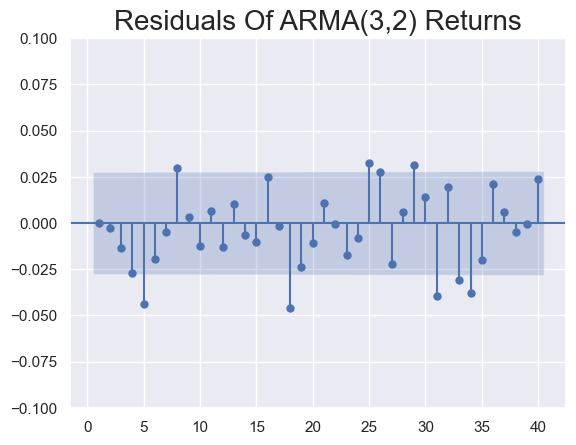

In [46]:
# Plot_acf for residuals of ARMA(3,2)
sgt.plot_acf(df.resid_ret_ar3_ma2[1:],zero=False,lags=40)
plt.title("Residuals Of ARMA(3,2) Returns",size=20)
plt.ylim(-.1,.1)
plt.show()

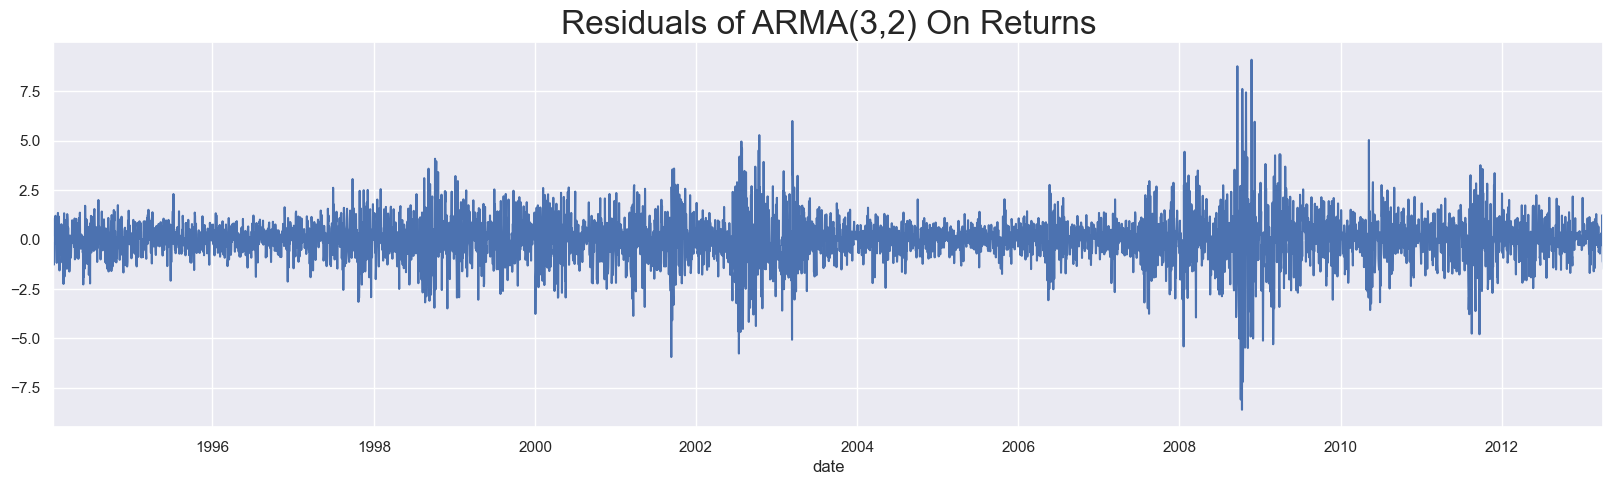

In [49]:
df.resid_ret_ar3_ma2[1:].plot(figsize=(20,5))
plt.title("Residuals of ARMA(3,2) On Returns",size=24)
plt.show()

`Looking at the residuals of ARMA(3,2) on returns we saw that most of the lags are not significant`                                                  
`But lag = 5 is significant, this shows that we might get a better model if we have either AR=5 or MA=5` 

## Reevaluating Model Selection

In [47]:
# Checking all the relevent ARMA(5,q) and ARMA(p,5) models
# starting with ARMA(5,5)
model_ret_ar5_ma5 = ARIMA(df.returns[1:], order=(5,0,5))
result_ret_ar5_ma5 = model_ret_ar5_ma5.fit()
print(result_ret_ar5_ma5.summary())

                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                 5020
Model:                 ARIMA(5, 0, 5)   Log Likelihood               -7883.185
Date:                Mon, 27 Apr 2026   AIC                          15790.369
Time:                        22:59:43   BIC                          15868.623
Sample:                    01-10-1994   HQIC                         15817.790
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0166      0.014      1.155      0.248      -0.012       0.045
ar.L1         -0.0611      0.125     -0.490      0.624      -0.305       0.183
ar.L2         -0.5273      0.080     -6.594      0.0

In [ ]:
# Checking LLR Test on ARMA(5,5) 
LLR_test(model_ret_ar3_ma3,model_ret_ar5_ma5,DF=4)
# Even though LLR Test suggests that ARMA(5,5) is a better fit and it is correct, but since only three of 10 coeffs are significant,
# we can say that we are overfitting the model

np.float64(0.0)

In [53]:
# Let us Try with either of the parts to be 5
for i in range(1,5):
    models= ARIMA(df.returns[1:], order=(i,0,5))
    results= models.fit()
    print(f'\tARMA({i},5) Model Summary ->  \n {results.summary()}')
    print()
    print("="*100)
    print("="*100)
    print()
    models = ARIMA(df.returns[1:], order=(5,0,i))
    results = models.fit()
    print(f'\tARMA(5,{i}) Model Summary ->  \n {results.summary()}')

	ARMA(1,5) Model Summary ->  
                                SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                 5020
Model:                 ARIMA(1, 0, 5)   Log Likelihood               -7890.974
Date:                Mon, 27 Apr 2026   AIC                          15797.949
Time:                        23:12:24   BIC                          15850.118
Sample:                    01-10-1994   HQIC                         15816.230
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0189      0.015      1.297      0.194      -0.010       0.047
ar.L1          0.3218      0.133      2.415      0.016       0.061       0.583
ma.L1         -0.3467

In [54]:
model_ret_ar5_ma2 = ARIMA(df.returns[1:], order=(5,0,2))
result_ret_ar5_ma2 = model_ret_ar5_ma2.fit()

model_ret_ar2_ma5 = ARIMA(df.returns[1:], order=(2,0,5))
result_ret_ar2_ma5 = model_ret_ar2_ma5.fit()


In [56]:
# From all these summaries we came to conclusion that ARMA(5,2) and ARMA(2,5) are the best fit
# Let us compare between them and choose the best one
# Since they both have equal DF so we can't run LLR TEST
# Thus we comapre with log likelihood value and AIC 
print(f'ARMA(5,2) ->\tLog-Likelihood Value -> {result_ret_ar5_ma2.llf}\t AIC Value -> {result_ret_ar5_ma2.aic}\t BIC Value -> {result_ret_ar5_ma2.bic}  ')
print(f'ARMA(2,5) ->\tLog-Likelihood Value -> {result_ret_ar2_ma5.llf}\t AIC Value -> {result_ret_ar2_ma5.aic}\t BIC Value -> {result_ret_ar2_ma5.bic}  ')


ARMA(5,2) ->	Log-Likelihood Value -> -7885.6667729563	 AIC Value -> 15789.3335459126	 BIC Value -> 15848.024212826771  
ARMA(2,5) ->	Log-Likelihood Value -> -7884.687708737267	 AIC Value -> 15787.375417474534	 BIC Value -> 15846.066084388705  


In [57]:
# We can see that ARMA(5,2) is better than ARMA(2,5) 
# Now We check if ARMA(3,2) is better than ARMA(5,2)
print(f'ARMA(5,2) ->\tLog-Likelihood Value -> {result_ret_ar5_ma2.llf}\t AIC Value -> {result_ret_ar5_ma2.aic}\t BIC Value -> {result_ret_ar5_ma2.bic}  ')
print(f'ARMA(3,2) ->\tLog-Likelihood Value -> {result_ret_ar3_ma2.llf}\t AIC Value -> {result_ret_ar3_ma2.aic}\t BIC Value -> {result_ret_ar3_ma2.bic}  ')

ARMA(5,2) ->	Log-Likelihood Value -> -7885.6667729563	 AIC Value -> 15789.3335459126	 BIC Value -> 15848.024212826771  
ARMA(3,2) ->	Log-Likelihood Value -> -7895.747490025818	 AIC Value -> 15805.494980051635	 BIC Value -> 15851.143276540435  


`Thus ARMA(5,2) is the best fit model after checking this`

In [58]:
df['resid_ret_ar5_ma2'] = result_ret_ar5_ma2.resid

In [59]:
df.head()

,market_value,returns,resid_ret_ar1_ma1,resid_ret_ar3_ma2,resid_ret_ar5_ma2
date,,,,,
1994-01-07,3445.98,NaN,NaN,NaN,NaN
1994-01-10,3440.58,-0.156704,-0.175606,-0.175531,-0.175603
1994-01-11,3413.77,-0.779229,-0.805937,-0.802104,-0.802184
1994-01-12,3372.02,-1.222988,-1.284980,-1.269908,-1.270011
1994-01-13,3360.01,-0.356166,-0.468570,-0.463282,-0.465980


## Residuals for the New Model

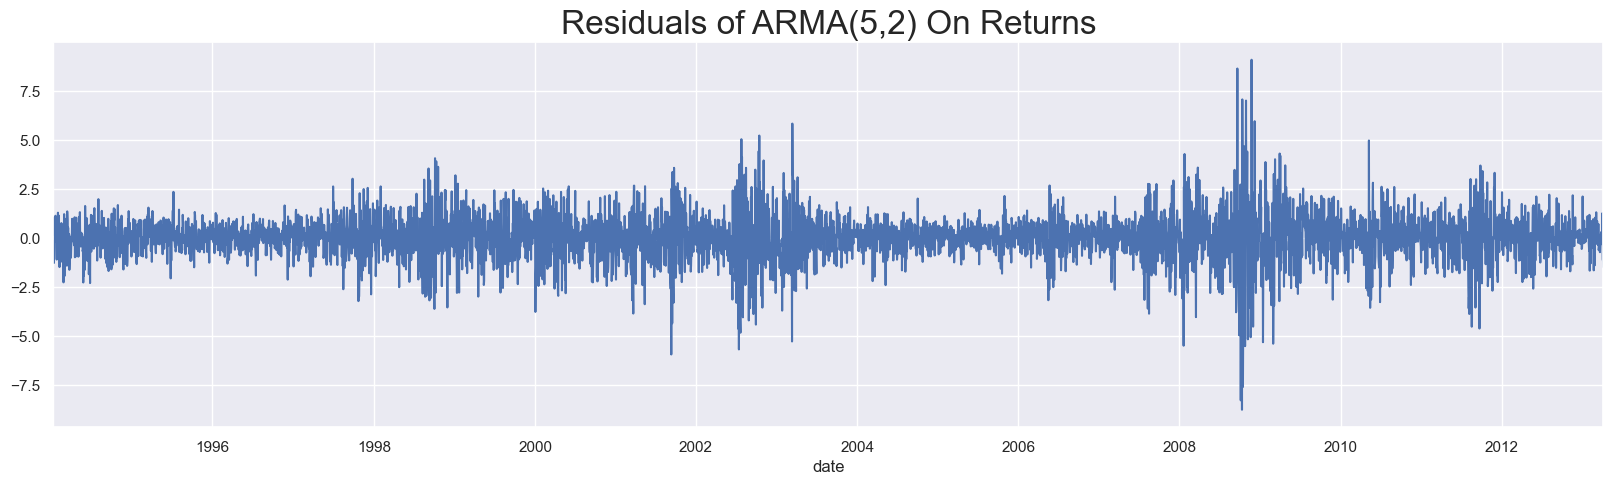

In [60]:
#Plotting Residuals of ARMA(5,2) 
df.resid_ret_ar5_ma2[1:].plot(figsize=(20,5))
plt.title("Residuals of ARMA(5,2) On Returns",size=24)
plt.show()

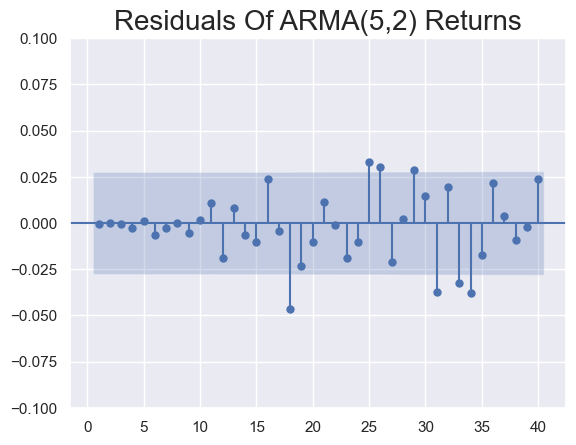

In [61]:
# Plotting ACF 
sgt.plot_acf(df.resid_ret_ar5_ma2[1:],zero=False,lags=40)
plt.title("Residuals Of ARMA(5,2) Returns",size=20)
plt.ylim(-.1,.1)
plt.show()

`Clearly First 17 Lags are all insignificant Thus we can say that this is the best fit model`                                                        
`And the Residuals are behaving like White Noise`

## ARMA Models for Prices

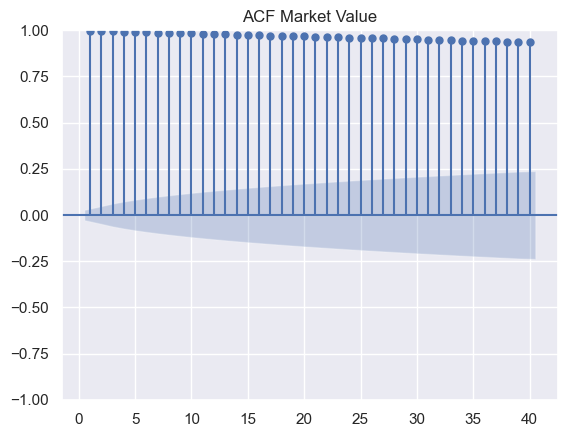

In [64]:
# ACF AND PACF ON PRICES
sgt.plot_acf(df.market_value,zero=False,lags=40)
plt.title("ACF Market Value")
plt.show()

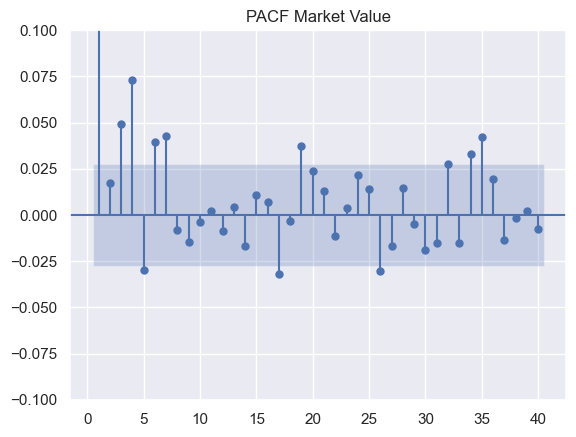

In [66]:
sgt.plot_pacf(df.market_value,zero=False,lags=40,alpha=0.05,method=('ols'))
plt.title("PACF Market Value")
plt.ylim(-.1,.1)
plt.show()

`We can take AR upto 6 lags after looking at PACF and ACF suggest MA(inf) but that is not possible but MA(inf) ~ AR(1)`                                 

`So we start with ARMA(1,1) and move forward`

In [67]:
# ARMA(1,1) on Prices
model_price_ar1_ma1 = ARIMA(df.market_value,order=(1,0,1))
result_price_ar1_ma1 = model_price_ar1_ma1.fit()
print(result_price_ar1_ma1.summary())

                               SARIMAX Results                                
Dep. Variable:           market_value   No. Observations:                 5021
Model:                 ARIMA(1, 0, 1)   Log Likelihood              -27621.875
Date:                Mon, 27 Apr 2026   AIC                          55251.749
Time:                        23:33:20   BIC                          55277.835
Sample:                    01-07-1994   HQIC                         55260.890
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5089.6409    366.501     13.887      0.000    4371.312    5807.970
ar.L1          0.9982      0.001   1189.159      0.000       0.997       1.000
ma.L1         -0.0186      0.010     -1.894      0.0

`MA component is insignificant ! thus we opt for higher fit model`

In [68]:
# Let us try ARMA(6,6) then move downward
model_price_ar6_ma6 = ARIMA(df.market_value,order=(6,0,6))
result_price_ar6_ma6 = model_price_ar6_ma6.fit()
print(result_price_ar6_ma6.summary())

                               SARIMAX Results                                
Dep. Variable:           market_value   No. Observations:                 5021
Model:                 ARIMA(6, 0, 6)   Log Likelihood              -27591.277
Date:                Mon, 27 Apr 2026   AIC                          55210.553
Time:                        23:34:39   BIC                          55301.853
Sample:                    01-07-1994   HQIC                         55242.546
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5089.6408    511.837      9.944      0.000    4086.458    6092.823
ar.L1          0.7382      0.926      0.797      0.425      -1.077       2.553
ar.L2          0.2445      1.555      0.157      0.8

`Not even a single component is significant Thus this is a bad fit` 

In [69]:
# Try ARMA(6,1) 
model_price_ar6_ma1 = ARIMA(df.market_value,order=(6,0,1))
result_price_ar6_ma1 = model_price_ar6_ma1.fit()
print(result_price_ar6_ma1.summary())

                               SARIMAX Results                                
Dep. Variable:           market_value   No. Observations:                 5021
Model:                 ARIMA(6, 0, 1)   Log Likelihood              -27594.195
Date:                Mon, 27 Apr 2026   AIC                          55206.389
Time:                        23:35:43   BIC                          55265.082
Sample:                    01-07-1994   HQIC                         55226.956
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5089.6310    525.600      9.683      0.000    4059.473    6119.789
ar.L1          1.3906      0.158      8.822      0.000       1.082       1.699
ar.L2         -0.4354      0.154     -2.831      0.0

`Clearly only one AR3 component is not significant, but LLF increased, AIC,BIC decreased -> ARMA(6,1) > ARMA(6,6) & ARMA(1,1)`

In [70]:
# Let us try with different ARMA models with AR component = 6
for i in range(2,6):
    model = ARIMA(df.market_value,order=(6,0,i))
    result= model.fit()
    print(f'ARMA(6,{i}) result summary \n{result.summary()}\n')

ARMA(6,2) result summary 
                               SARIMAX Results                                
Dep. Variable:           market_value   No. Observations:                 5021
Model:                 ARIMA(6, 0, 2)   Log Likelihood              -27590.600
Date:                Mon, 27 Apr 2026   AIC                          55201.200
Time:                        23:39:17   BIC                          55266.414
Sample:                    01-07-1994   HQIC                         55224.051
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5089.6408   1477.738      3.444      0.001    2193.327    7985.955
ar.L1          1.1939      0.051     23.402      0.000       1.094       1.294
ar.L2         -1.0582     

`Conclusion -> ARMA(6,2) is the best fit amongst all the models`

In [71]:
model_price_ar6_ma2 = ARIMA(df.market_value,order=(6,0,2))
result_price_ar6_ma2 = model_price_ar6_ma2.fit()

In [79]:
# Checking The Residuals of ARMA(6,2) 
df['resid_price_ar6_ma2'] = result_price_ar6_ma2.resid[1:]

In [80]:
df.head()

,market_value,returns,resid_ret_ar1_ma1,resid_ret_ar3_ma2,resid_ret_ar5_ma2,resid_price_ar6_ma_2,resid_price_ar6_ma2
date,,,,,,,
1994-01-07,3445.98,NaN,NaN,NaN,NaN,NaN,NaN
1994-01-10,3440.58,-0.156704,-0.175606,-0.175531,-0.175603,-6.264364,-6.264364
1994-01-11,3413.77,-0.779229,-0.805937,-0.802104,-0.802184,-27.757224,-27.757224
1994-01-12,3372.02,-1.222988,-1.284980,-1.269908,-1.270011,-43.335074,-43.335074
1994-01-13,3360.01,-0.356166,-0.468570,-0.463282,-0.465980,-15.462211,-15.462211


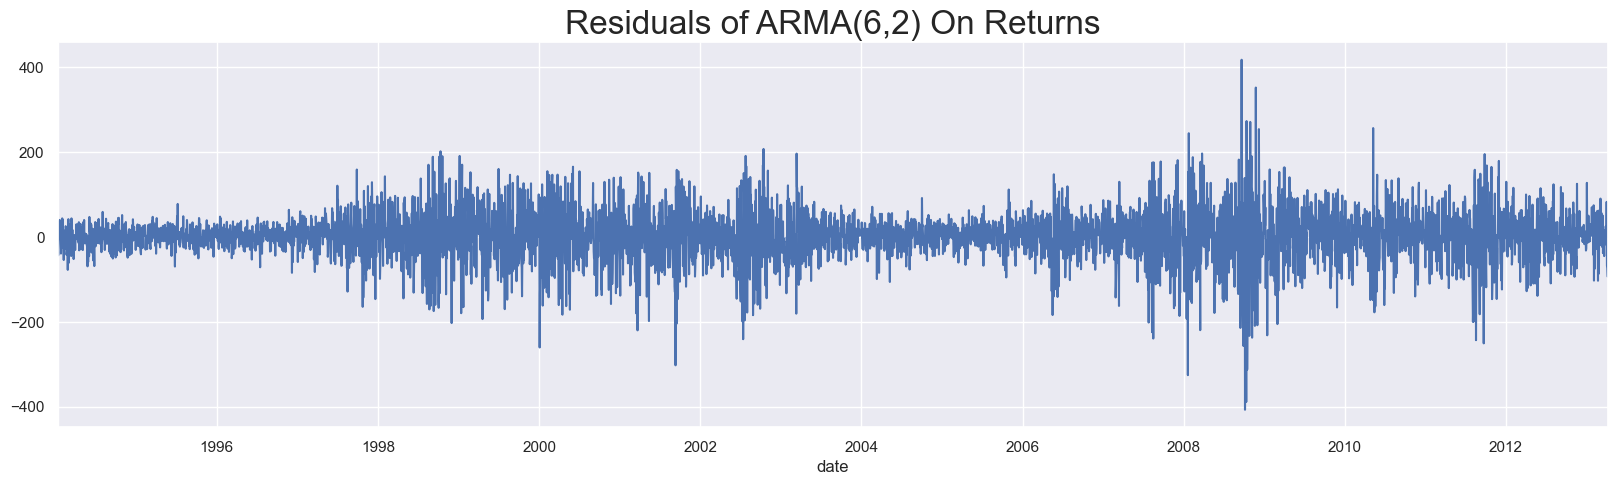

In [81]:
#Plotting Residuals of ARMA(6,2) On Prices
df.resid_price_ar6_ma2[1:].plot(figsize=(20,5))
plt.title("Residuals of ARMA(6,2) On Returns",size=24)
plt.show()


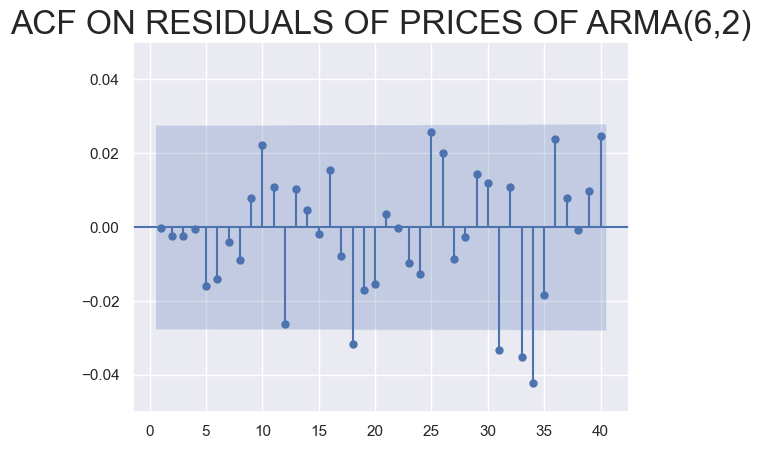

In [83]:
# Plotting ACF
sgt.plot_acf(df.resid_price_ar6_ma2[1:],zero=False,lags=40)
plt.title("ACF ON RESIDUALS OF PRICES OF ARMA(6,2)",size=24)
plt.ylim(-.05,.05)
plt.show()

`Clearly First 17 lags are all ~~ 0 thus we have a good Model`

## ARMA for Returns vs ARMA for Prices

In [84]:
# Chekcing ARMA FOR Returns VS ARMA FOR Prices
print(f'ARMA(6,2) PRICES ->\tLog-Likelihood Value -> {result_price_ar6_ma2.llf}\t AIC Value -> {result_price_ar6_ma2.aic}\t BIC Value -> {result_price_ar6_ma2.bic}  ')
print(f'ARMA(5,2) RETURNS ->\tLog-Likelihood Value -> {result_ret_ar5_ma2.llf}\t AIC Value -> {result_ret_ar5_ma2.aic}\t BIC Value -> {result_ret_ar5_ma2.bic}  ')

ARMA(6,2) PRICES ->	Log-Likelihood Value -> -27590.599934640602	 AIC Value -> 55201.199869281205	 BIC Value -> 55266.41371324155  
ARMA(5,2) RETURNS ->	Log-Likelihood Value -> -7885.6667729563	 AIC Value -> 15789.3335459126	 BIC Value -> 15848.024212826771  


`IT IS PRETTY CLEAR THAT ARMA GIVES A MUCH MUCH BETTER RESULT WHEN DEALING WITH STAIIONARY DATA LIKE RETURNS AND NOT WITH NON STATIONARY DATA LIKE PRICES`